# Bosch 제조 공정 병목 탐지 모델링 - Colab

이 노트북은 Bosch Production Line Performance 데이터에서 **불량 전이 예측을 제외**하고, **제조 병목 탐지**만 수행하도록 구성했습니다.

사용 데이터셋은 2개입니다.

- `train_date.csv`: Station 통과 시간, 공정 흐름, 체류 시간 기반 병목 피처 생성
- `train_numeric.csv`: 수치형 공정/센서 피처 보강용으로만 사용

주의사항:

- `train_numeric.csv`에 `Response` 컬럼이 있어도 사용하지 않습니다.
- 병목 정답 라벨이 없기 때문에 지도학습 분류 모델은 제외합니다.
- 병목 탐지는 `Rule Engine + Isolation Forest` 방식으로 수행합니다.


In [1]:

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


In [2]:
# CPU 병렬 사용
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)

## 1. 데이터 로드

Colab 기준으로 Google Drive의 데이터 폴더를 사용합니다.

기본 경로는 `/content/drive/MyDrive/aims_dataset`입니다. 데이터 위치가 다르면 `DATA_DIR`만 수정하면 됩니다.


In [3]:

from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

DATA_DIR = Path('/content/drive/MyDrive/aims_dataset')

DATE_FILENAME = "train_date.csv"
NUMERIC_FILENAME = "train_numeric.csv"

# 병목 탐지에서 사용하는 Bosch 데이터셋 2개
# train_date.csv: 공정/Station별 시간 데이터
# train_numeric.csv: 수치형 공정/센서 데이터, 단 Response 컬럼은 제외함

NROWS_DATE = 100_000
NROWS_NUMERIC = 120_000

DATE_PATH = DATA_DIR / DATE_FILENAME
NUMERIC_PATH = DATA_DIR / NUMERIC_FILENAME

print("DATE_PATH:", DATE_PATH)
print("NUMERIC_PATH:", NUMERIC_PATH)
print("DATE exists:", DATE_PATH.exists())
print("NUMERIC exists:", NUMERIC_PATH.exists())

if not DATE_PATH.exists():
    raise FileNotFoundError(f"{DATE_FILENAME} 파일을 찾지 못했습니다: {DATE_PATH}")

if not NUMERIC_PATH.exists():
    raise FileNotFoundError(f"{NUMERIC_FILENAME} 파일을 찾지 못했습니다: {NUMERIC_PATH}")

# Colab 메모리 사용량을 고려해 샘플 행 수만 로드함
# 전체 학습 시에는 nrows 옵션을 제거하거나 값을 늘리면 됨
date_df = pd.read_csv(DATE_PATH, nrows=NROWS_DATE)
numeric_df = pd.read_csv(NUMERIC_PATH, nrows=NROWS_NUMERIC)

# 불량 전이/불량 예측에 사용되는 Response 컬럼은 병목 탐지에서 제외함
if "Response" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["Response"])
    print("Response 컬럼 제거 완료: 병목 탐지에서는 사용하지 않음")

print("date_df shape:", date_df.shape)
print("numeric_df shape:", numeric_df.shape)


DATE_PATH: /content/drive/MyDrive/aims_dataset/train_date.csv
NUMERIC_PATH: /content/drive/MyDrive/aims_dataset/train_numeric.csv
DATE exists: True
NUMERIC exists: True
Response 컬럼 제거 완료: 병목 탐지에서는 사용하지 않음
date_df shape: (100000, 1157)
numeric_df shape: (120000, 969)


## 2. 컬럼 구조 파악 및 결측치 확인

Bosch 컬럼명은 다음 형식으로 구성됩니다.

- Date 컬럼 예시: `L0_S0_D1`
- Numeric 컬럼 예시: `L0_S0_F0`

여기서는 컬럼명에서 Line과 Station 정보를 추출해 공정 단위 피처를 생성합니다.


In [5]:

# Bosch 컬럼명 패턴 정의
DATE_COL_PATTERN = re.compile(r"^(L\d+)_S(\d+)_D\d+$")
NUMERIC_COL_PATTERN = re.compile(r"^(L\d+)_S(\d+)_F\d+$")


def parse_process_columns(columns, pattern, value_type):
    rows = []

    for col in columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "line": match.group(1),
                "station": f"S{match.group(2)}",
                "value_type": value_type,
            })

    return pd.DataFrame(rows)


date_meta = parse_process_columns(date_df.columns, DATE_COL_PATTERN, "date")
numeric_meta = parse_process_columns(numeric_df.columns, NUMERIC_COL_PATTERN, "numeric")

print("date columns:", len(date_meta))
print("numeric columns:", len(numeric_meta))

display(date_meta.head())
display(numeric_meta.head())


date columns: 1156
numeric columns: 968


,column,line,station,value_type
0,L0_S0_D1,L0,S0,date
1,L0_S0_D3,L0,S0,date
2,L0_S0_D5,L0,S0,date
3,L0_S0_D7,L0,S0,date
4,L0_S0_D9,L0,S0,date


,column,line,station,value_type
0,L0_S0_F0,L0,S0,numeric
1,L0_S0_F2,L0,S0,numeric
2,L0_S0_F4,L0,S0,numeric
3,L0_S0_F6,L0,S0,numeric
4,L0_S0_F8,L0,S0,numeric


date missing top 20


,column,missing_ratio
0,L3_S46_D4135,1.00000
1,L3_S42_D4057,1.00000
2,L3_S42_D4053,1.00000
3,L3_S42_D4049,1.00000
4,L3_S42_D4045,1.00000
5,L1_S24_D1158,1.00000
6,L3_S42_D4037,0.99999
7,L3_S42_D4033,0.99999
8,L3_S42_D4029,0.99999
9,L3_S42_D4041,0.99999


numeric missing top 20


,column,missing_ratio
0,L1_S25_F2181,0.999125
1,L1_S25_F2202,0.999125
2,L1_S25_F2190,0.999125
3,L1_S25_F2193,0.999125
4,L1_S25_F2187,0.999125
5,L1_S25_F2184,0.999125
6,L1_S25_F2199,0.999125
7,L1_S25_F2196,0.999125
8,L1_S25_F2608,0.998217
9,L1_S25_F2623,0.998217


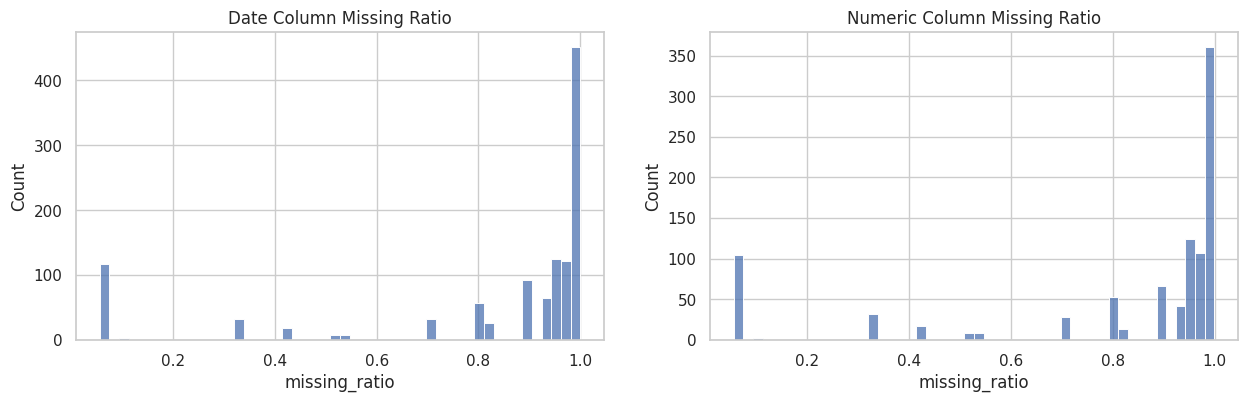

In [6]:

# date 데이터의 컬럼별 결측치 비율 계산
date_missing_summary = (
    date_df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
    .reset_index()
    .rename(columns={"index": "column"})
)

# numeric 데이터의 컬럼별 결측치 비율 계산
numeric_missing_summary = (
    numeric_df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
    .reset_index()
    .rename(columns={"index": "column"})
)

print("date missing top 20")
display(date_missing_summary.head(20))

print("numeric missing top 20")
display(numeric_missing_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(
    date_missing_summary.loc[date_missing_summary["column"] != "Id", "missing_ratio"],
    bins=50,
    ax=axes[0],
)
axes[0].set_title("Date Column Missing Ratio")

sns.histplot(
    numeric_missing_summary.loc[numeric_missing_summary["column"] != "Id", "missing_ratio"],
    bins=50,
    ax=axes[1],
)
axes[1].set_title("Numeric Column Missing Ratio")

plt.show()


## 3. 병목 탐지 Feature 생성

병목 탐지를 위해 다음 피처를 생성합니다.

- 제품 전체 공정 시작/종료/총 체류 시간
- Line별 공정 소요 시간, 관측 수, 결측 비율
- Station별 통과 여부, 체류 시간, 평균 시간, 표준편차
- 가장 긴 Station 체류 시간과 해당 Station
- Numeric 데이터의 제품별/Line별/Station별 수치 통계

`Response`는 이미 제거했으므로 불량 예측 관련 정보는 사용하지 않습니다.


In [7]:

def safe_row_quantile(frame, q):
    return frame.quantile(q=q, axis=1, numeric_only=True)


def build_date_bottleneck_features(raw_df, column_meta):
    if column_meta.empty:
        raise ValueError("date 컬럼 메타데이터가 비어 있습니다. train_date.csv 컬럼명을 확인하세요.")

    feature_df = pd.DataFrame({"Id": raw_df["Id"]})
    date_cols = column_meta["column"].tolist()

    row_min = raw_df[date_cols].min(axis=1)
    row_max = raw_df[date_cols].max(axis=1)

    # 제품 단위 전체 공정 흐름 피처
    feature_df["process_start_time"] = row_min
    feature_df["process_end_time"] = row_max
    feature_df["total_duration"] = row_max - row_min
    feature_df["observed_date_count"] = raw_df[date_cols].notna().sum(axis=1)
    feature_df["date_missing_ratio"] = raw_df[date_cols].isna().mean(axis=1)

    station_span_cols = []

    # Station 단위 시간 피처
    for (line, station), group in column_meta.groupby(["line", "station"], sort=True):
        cols = group["column"].tolist()
        prefix = f"{line}_{station}"

        station_min = raw_df[cols].min(axis=1)
        station_max = raw_df[cols].max(axis=1)
        station_span = station_max - station_min

        feature_df[f"{prefix}_seen"] = raw_df[cols].notna().any(axis=1).astype("int8")
        feature_df[f"{prefix}_span"] = station_span
        feature_df[f"{prefix}_mean_time"] = raw_df[cols].mean(axis=1)
        feature_df[f"{prefix}_std_time"] = raw_df[cols].std(axis=1)
        station_span_cols.append(f"{prefix}_span")

    # Line 단위 시간 피처
    for line, group in column_meta.groupby("line", sort=True):
        cols = group["column"].tolist()
        line_min = raw_df[cols].min(axis=1)
        line_max = raw_df[cols].max(axis=1)

        feature_df[f"{line}_seen"] = raw_df[cols].notna().any(axis=1).astype("int8")
        feature_df[f"{line}_duration"] = line_max - line_min
        feature_df[f"{line}_date_count"] = raw_df[cols].notna().sum(axis=1)
        feature_df[f"{line}_date_missing_ratio"] = raw_df[cols].isna().mean(axis=1)

    station_spans = feature_df[station_span_cols]
    station_seen_cols = [c for c in feature_df.columns if re.match(r"^L\d+_S\d+_seen$", c)]

    feature_df["max_station_span"] = station_spans.max(axis=1)
    feature_df["mean_station_span"] = station_spans.mean(axis=1)
    feature_df["std_station_span"] = station_spans.std(axis=1)
    feature_df["active_station_count"] = feature_df[station_seen_cols].sum(axis=1)
    feature_df["bottleneck_station"] = station_spans.idxmax(axis=1).str.replace("_span", "", regex=False)

    return feature_df, station_span_cols


def build_numeric_bottleneck_features(raw_df, column_meta):
    if column_meta.empty:
        raise ValueError("numeric 컬럼 메타데이터가 비어 있습니다. train_numeric.csv 컬럼명을 확인하세요.")

    feature_df = pd.DataFrame({"Id": raw_df["Id"]})
    num_cols = column_meta["column"].tolist()
    values = raw_df[num_cols]

    # 제품 단위 수치형 요약 피처
    feature_df["num_observed_count"] = values.notna().sum(axis=1)
    feature_df["num_missing_ratio"] = values.isna().mean(axis=1)
    feature_df["num_mean"] = values.mean(axis=1)
    feature_df["num_std"] = values.std(axis=1)
    feature_df["num_min"] = values.min(axis=1)
    feature_df["num_max"] = values.max(axis=1)
    feature_df["num_range"] = feature_df["num_max"] - feature_df["num_min"]
    feature_df["num_q10"] = safe_row_quantile(values, 0.10)
    feature_df["num_q50"] = safe_row_quantile(values, 0.50)
    feature_df["num_q90"] = safe_row_quantile(values, 0.90)

    # Line 단위 수치형 요약 피처
    for line, group in column_meta.groupby("line", sort=True):
        cols = group["column"].tolist()
        line_values = raw_df[cols]

        feature_df[f"{line}_num_count"] = line_values.notna().sum(axis=1)
        feature_df[f"{line}_num_missing_ratio"] = line_values.isna().mean(axis=1)
        feature_df[f"{line}_num_mean"] = line_values.mean(axis=1)
        feature_df[f"{line}_num_std"] = line_values.std(axis=1)
        feature_df[f"{line}_num_range"] = line_values.max(axis=1) - line_values.min(axis=1)

    # Station 단위 수치형 요약 피처
    for (line, station), group in column_meta.groupby(["line", "station"], sort=True):
        cols = group["column"].tolist()
        station_values = raw_df[cols]
        prefix = f"{line}_{station}_num"

        feature_df[f"{prefix}_seen"] = station_values.notna().any(axis=1).astype("int8")
        feature_df[f"{prefix}_missing_ratio"] = station_values.isna().mean(axis=1)
        feature_df[f"{prefix}_mean"] = station_values.mean(axis=1)
        feature_df[f"{prefix}_std"] = station_values.std(axis=1)

    return feature_df


# date 기반 병목 피처 생성
date_features, station_span_cols = build_date_bottleneck_features(date_df, date_meta)

# numeric 기반 보조 피처 생성
numeric_features = build_numeric_bottleneck_features(numeric_df, numeric_meta)

# Id 기준으로 train_date.csv + train_numeric.csv 피처 병합
features = date_features.merge(numeric_features, on="Id", how="inner", suffixes=("_date", "_num"))

if len(features) < 100:
    raise ValueError("date/numeric Id 매칭 결과가 너무 적습니다. 두 파일의 샘플링 범위를 확인하세요.")

print("date_features:", date_features.shape)
print("numeric_features:", numeric_features.shape)
print("merged bottleneck features:", features.shape)

display(features.head())


date_features: (100000, 235)
numeric_features: (120000, 231)
merged bottleneck features: (100000, 465)


,Id,process_start_time,process_end_time,total_duration,observed_date_count,date_missing_ratio,L0_S0_seen,L0_S0_span,L0_S0_mean_time,L0_S0_std_time,L0_S1_seen,L0_S1_span,L0_S1_mean_time,L0_S1_std_time,L0_S10_seen,L0_S10_span,L0_S10_mean_time,L0_S10_std_time,L0_S11_seen,L0_S11_span,L0_S11_mean_time,L0_S11_std_time,L0_S12_seen,L0_S12_span,L0_S12_mean_time,L0_S12_std_time,L0_S13_seen,L0_S13_span,L0_S13_mean_time,L0_S13_std_time,L0_S14_seen,L0_S14_span,L0_S14_mean_time,L0_S14_std_time,L0_S15_seen,L0_S15_span,L0_S15_mean_time,L0_S15_std_time,L0_S16_seen,L0_S16_span,L0_S16_mean_time,L0_S16_std_time,L0_S17_seen,L0_S17_span,L0_S17_mean_time,L0_S17_std_time,L0_S18_seen,L0_S18_span,L0_S18_mean_time,L0_S18_std_time,L0_S19_seen,L0_S19_span,L0_S19_mean_time,L0_S19_std_time,L0_S2_seen,L0_S2_span,L0_S2_mean_time,L0_S2_std_time,L0_S20_seen,L0_S20_span,L0_S20_mean_time,L0_S20_std_time,L0_S21_seen,L0_S21_span,L0_S21_mean_time,L0_S21_std_time,L0_S22_seen,L0_S22_span,L0_S22_mean_time,L0_S22_std_time,...,L3_S32_num_mean,L3_S32_num_std,L3_S33_num_seen,L3_S33_num_missing_ratio,L3_S33_num_mean,L3_S33_num_std,L3_S34_num_seen,L3_S34_num_missing_ratio,L3_S34_num_mean,L3_S34_num_std,L3_S35_num_seen,L3_S35_num_missing_ratio,L3_S35_num_mean,L3_S35_num_std,L3_S36_num_seen,L3_S36_num_missing_ratio,L3_S36_num_mean,L3_S36_num_std,L3_S37_num_seen,L3_S37_num_missing_ratio,L3_S37_num_mean,L3_S37_num_std,L3_S38_num_seen,L3_S38_num_missing_ratio,L3_S38_num_mean,L3_S38_num_std,L3_S39_num_seen,L3_S39_num_missing_ratio,L3_S39_num_mean,L3_S39_num_std,L3_S40_num_seen,L3_S40_num_missing_ratio,L3_S40_num_mean,L3_S40_num_std,L3_S41_num_seen,L3_S41_num_missing_ratio,L3_S41_num_mean,L3_S41_num_std,L3_S43_num_seen,L3_S43_num_missing_ratio,L3_S43_num_mean,L3_S43_num_std,L3_S44_num_seen,L3_S44_num_missing_ratio,L3_S44_num_mean,L3_S44_num_std,L3_S45_num_seen,L3_S45_num_missing_ratio,L3_S45_num_mean,L3_S45_num_std,L3_S47_num_seen,L3_S47_num_missing_ratio,L3_S47_num_mean,L3_S47_num_std,L3_S48_num_seen,L3_S48_num_missing_ratio,L3_S48_num_mean,L3_S48_num_std,L3_S49_num_seen,L3_S49_num_missing_ratio,L3_S49_num_mean,L3_S49_num_std,L3_S50_num_seen,L3_S50_num_missing_ratio,L3_S50_num_mean,L3_S50_num_std,L3_S51_num_seen,L3_S51_num_missing_ratio,L3_S51_num_mean,L3_S51_num_std
0,4,82.24,87.29,5.05,179,0.845156,1,0.0,82.24,0.000000e+00,1,0.0,82.24,0.0,0,NaN,NaN,NaN,1,0.0,82.27,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,82.24,0.000000e+00,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,...,NaN,NaN,1,0.0,-0.0481,0.060306,1,0.0,0.0,0.0,1,0.0,-0.014125,0.028518,0,1.0,NaN,NaN,1,0.0,0.0,0.0,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN
1,6,1313.12,1315.75,2.63,209,0.819204,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1313.12,2.374841e-13,1,0.0,1313.12,0.0,1,0.0,1313.12,0.0,0,NaN,NaN,NaN,1,0.0,1313.14,0.0,0,NaN,NaN,NaN,1,0.0,1313.15,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1313.15,0.0,1,0.0,1313.15,0.0,0,NaN,NaN,NaN,...,NaN,NaN,1,0.0,-0.0370,0.063085,1,0.0,0.0,0.0,1,0.0,-0.001125,0.016013,0,1.0,NaN,NaN,1,0.0,0.0,0.0,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN
2,7,1618.70,1624.42,5.72,207,0.820934,1,0.0,1618.70,4.749681e-13,1,0.0,1618.70,0.0,1,0.0,1618.73,2.366580e-13,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1618.70,2.411662e-13,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,...,NaN,NaN,1,0.0,0.1132,0.102470,1,0.0,0.0,0.0,1,0.0,-0.012125,0.036451,0,1.0,NaN,NaN,1,0.0,0.0,0.0,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN
3,9,1149.20,1154.16,4.96,207,0.820934,1,0.0,1149.2

In [8]:

# 생성된 병목 Feature의 결측치 비율 상위 20개 확인
feature_missing = features.isna().mean().sort_values(ascending=False).head(20)
display(feature_missing)

# 병목 탐지에 사용할 핵심 Feature들의 분포 확인
summary_cols = [
    "total_duration",
    "observed_date_count",
    "active_station_count",
    "max_station_span",
    "mean_station_span",
    "num_observed_count",
    "num_missing_ratio",
    "num_mean",
    "num_std",
]

display(features[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


,0
L3_S32_num_std,1.00000
L3_S32_std_time,1.00000
L3_S46_span,1.00000
L3_S46_mean_time,1.00000
L3_S46_std_time,1.00000
L3_S42_span,0.99999
L3_S42_mean_time,0.99999
L3_S42_std_time,0.99999
L2_S28_std_time,0.99292
L2_S28_num_mean,0.99292


,total_duration,observed_date_count,active_station_count,max_station_span,mean_station_span,num_observed_count,num_missing_ratio,num_mean,num_std
count,99950.000000,100000.000000,100000.000000,99950.000000,99950.000000,100000.000000,100000.000000,99950.000000,99950.000000
mean,10.669247,204.563850,12.185120,0.144824,0.018061,182.584520,0.811380,0.000084,0.119714
std,17.287234,32.457079,2.401226,1.267011,0.157999,26.075502,0.026938,0.013448,0.020593
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.662190,-0.150667,0.000000
50%,3.770000,207.000000,13.000000,0.000000,0.000000,190.000000,0.803719,0.000271,0.115496
75%,11.660000,233.000000,13.000000,0.000000,0.000000,202.000000,0.834711,0.008400,0.126574
90%,35.530000,249.000000,14.000000,0.030000,0.004286,210.000000,0.836777,0.016110,0.143375
95%,42.900000,249.000000,15.000000,0.120000,0.015000,210.000000,0.881198,0.020937,0.153553
99%,61.590000,262.000000,16.000000,6.015100,0.750637,220.000000,0.886364,0.030333,0.222472
max,376.180000,399.000000,21.000000,34.250000,4.281250,327.000000,1.000000,0.068937,0.302976


## 4. Rule Engine 병목 탐지

병목 정답 라벨이 없으므로, 운영 기준에 가까운 Rule 기반 pseudo label을 먼저 생성합니다.

기본 기준은 다음과 같습니다.

- 전체 공정 체류 시간이 상위 5% 이상
- Station 최대 체류 시간이 상위 5% 이상

운영 환경에서는 이 기준을 `평균 대비 30% 증가`, `SLA 초과`, `대기열 급증` 같은 실제 업무 임계값으로 교체하면 됩니다.


In [9]:

def apply_rule_engine(feature_df, duration_q=0.95, station_span_q=0.95):
    result = feature_df.copy()

    duration_threshold = result["total_duration"].quantile(duration_q)
    station_span_threshold = result["max_station_span"].quantile(station_span_q)

    duration_score = (
        result["total_duration"] / max(duration_threshold, 1e-12)
    ).clip(upper=2.0) / 2.0

    station_span_score = (
        result["max_station_span"] / max(station_span_threshold, 1e-12)
    ).clip(upper=2.0) / 2.0

    result["rule_risk_score"] = (
        0.55 * duration_score +
        0.45 * station_span_score
    ).fillna(0)

    result["rule_bottleneck"] = (
        (result["total_duration"] >= duration_threshold) |
        (result["max_station_span"] >= station_span_threshold)
    ).astype(int)

    thresholds = {
        "duration_threshold": duration_threshold,
        "station_span_threshold": station_span_threshold,
    }

    return result, thresholds


rule_result, rule_thresholds = apply_rule_engine(features)

print(rule_thresholds)
print("rule_bottleneck count:")
print(rule_result["rule_bottleneck"].value_counts(dropna=False))
print("rule_bottleneck ratio:")
print(rule_result["rule_bottleneck"].value_counts(normalize=True, dropna=False))

display(
    rule_result
    .sort_values("rule_risk_score", ascending=False)
    .head(10)[[
        "Id",
        "bottleneck_station",
        "total_duration",
        "max_station_span",
        "active_station_count",
        "rule_risk_score",
        "rule_bottleneck",
    ]]
)


{'duration_threshold': np.float64(42.89999999999998), 'station_span_threshold': np.float64(0.11999999999989086)}
rule_bottleneck count:
rule_bottleneck
0    91122
1     8878
Name: count, dtype: int64
rule_bottleneck ratio:
rule_bottleneck
0    0.91122
1    0.08878
Name: proportion, dtype: float64


,Id,bottleneck_station,total_duration,max_station_span,active_station_count,rule_risk_score,rule_bottleneck
16022,32043,L1_S25,371.76,0.24,8,1.000000,1
50090,100314,L1_S25,371.58,0.29,8,1.000000,1
79484,159285,L1_S25,115.12,22.94,8,1.000000,1
41633,83366,L1_S25,115.38,23.20,8,1.000000,1
83062,166646,L1_S25,87.41,15.00,9,1.000000,1
83379,167223,L1_S25,114.01,20.51,8,1.000000,1
89593,179438,L1_S25,112.18,18.76,8,1.000000,1
62280,124663,L1_S25,83.19,10.73,8,0.983269,1
52653,105485,L1_S25,371.75,0.23,8,0.981250,1
19724,39502,L1_S25,371.68,0.21,8,0.943750,1


## 5. Isolation Forest 병목 탐지

Isolation Forest는 정답 라벨 없이 정상 흐름에서 벗어난 제품 흐름을 탐지합니다.

여기서는 `train_date.csv`에서 만든 시간/Station 피처와 `train_numeric.csv`에서 만든 수치형 보조 피처를 함께 사용합니다.


In [10]:

# Isolation Forest에 사용할 병목 탐지 Feature 목록 구성
base_model_features = [
    "total_duration",
    "observed_date_count",
    "date_missing_ratio",
    "active_station_count",
    "max_station_span",
    "mean_station_span",
    "std_station_span",
    "num_observed_count",
    "num_missing_ratio",
    "num_mean",
    "num_std",
    "num_range",
    "num_q10",
    "num_q50",
    "num_q90",
]

line_date_features = [
    c for c in features.columns
    if re.match(r"^L\d+_(duration|date_count|date_missing_ratio)$", c)
]

line_numeric_features = [
    c for c in features.columns
    if re.match(r"^L\d+_num_(count|missing_ratio|mean|std|range)$", c)
]

station_numeric_features = [
    c for c in features.columns
    if re.match(r"^L\d+_S\d+_num_(seen|missing_ratio|mean|std)$", c)
]

model_features = base_model_features + line_date_features + line_numeric_features + station_numeric_features
model_features = [c for c in model_features if c in features.columns]

X = features[model_features].select_dtypes(include=[np.number, "bool"]).copy()

# Rule 기반 병목 비율을 참고하여 Isolation Forest의 이상치 비율 설정
contamination = max(0.01, min(0.10, rule_result["rule_bottleneck"].mean()))

iforest_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

iforest_pipeline.fit(X)
if_pred_raw = iforest_pipeline.predict(X)

X_imputed_scaled = iforest_pipeline.named_steps["scaler"].transform(
    iforest_pipeline.named_steps["imputer"].transform(X)
)

# decision_function 값이 낮을수록 이상치에 가까우므로 음수로 변환함
if_scores_raw = iforest_pipeline.named_steps["model"].decision_function(X_imputed_scaled)

iforest_result = rule_result.copy()
iforest_result["iforest_bottleneck"] = (if_pred_raw == -1).astype(int)
iforest_result["iforest_anomaly_score"] = -if_scores_raw
iforest_result["iforest_risk_score"] = iforest_result["iforest_anomaly_score"].rank(pct=True)

print("model feature count:", len(model_features))
print("contamination:", contamination)
display(iforest_result["iforest_bottleneck"].value_counts(normalize=True).rename("ratio"))

display(
    iforest_result
    .sort_values("iforest_risk_score", ascending=False)
    .head(10)[[
        "Id",
        "bottleneck_station",
        "total_duration",
        "max_station_span",
        "rule_risk_score",
        "iforest_risk_score",
        "rule_bottleneck",
        "iforest_bottleneck",
    ]]
)


model feature count: 247
contamination: 0.08878


,ratio
iforest_bottleneck,
0,0.91122
1,0.08878


,Id,bottleneck_station,total_duration,max_station_span,rule_risk_score,iforest_risk_score,rule_bottleneck,iforest_bottleneck
99498,199312,L0_S12,7.90,0.00,0.050641,1.00000,0,1
81200,162806,L0_S12,7.65,0.00,0.049038,0.99999,0,1
80134,160620,L1_S24,19.85,0.01,0.145994,0.99998,0,1
32674,65442,L0_S12,7.89,0.00,0.050577,0.99997,0,1
44699,89364,L0_S12,7.84,0.00,0.050256,0.99996,0,1
80033,160411,L0_S12,0.65,0.00,0.004167,0.99995,0,1
73175,146361,L0_S12,0.66,0.00,0.004231,0.99994,0,1
84685,169786,L1_S24,8.24,0.03,0.109071,0.99993,0,1
14467,28884,L1_S24,8.26,0.03,0.109199,0.99992,0,1
43809,87664,L0_S12,7.65,0.00,0.049038,0.99991,0,1


## 6. 시각화

제품 단위 위험도와 Station 단위 병목 후보를 확인합니다.


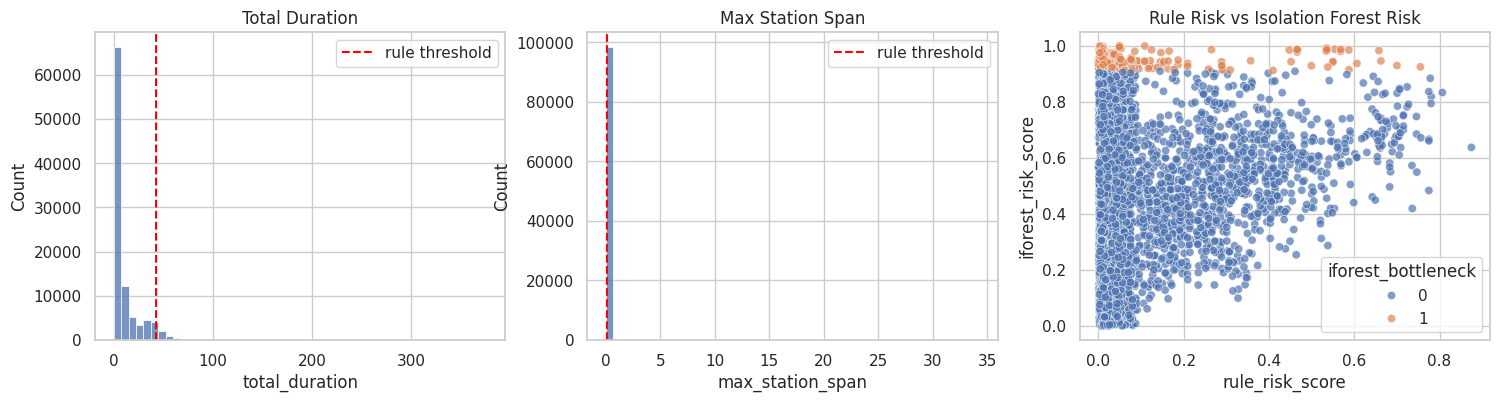

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(iforest_result["total_duration"], bins=50, ax=axes[0])
axes[0].axvline(
    rule_thresholds["duration_threshold"],
    color="red",
    linestyle="--",
    label="rule threshold",
)
axes[0].set_title("Total Duration")
axes[0].legend()

sns.histplot(iforest_result["max_station_span"], bins=50, ax=axes[1])
axes[1].axvline(
    rule_thresholds["station_span_threshold"],
    color="red",
    linestyle="--",
    label="rule threshold",
)
axes[1].set_title("Max Station Span")
axes[1].legend()

sns.scatterplot(
    data=iforest_result.sample(min(len(iforest_result), 5000), random_state=RANDOM_STATE),
    x="rule_risk_score",
    y="iforest_risk_score",
    hue="iforest_bottleneck",
    alpha=0.7,
    ax=axes[2],
)
axes[2].set_title("Rule Risk vs Isolation Forest Risk")

plt.show()


,bottleneck_station,impacted_products,avg_total_duration,avg_max_station_span,avg_rule_risk,avg_iforest_risk
0,L1_S25,5818,42.285889,2.390961,0.525915,0.642507
1,L0_S12,4305,5.995127,0.000000,0.037858,0.947871
2,L0_S0,3960,6.617697,0.000000,0.039752,0.951312
3,L1_S24,2973,50.180340,0.044719,0.387686,0.620131
4,L3_S39,6,0.561667,0.000000,0.003600,0.975422
5,L3_S38,4,0.000000,0.000000,0.000000,0.945802
6,L0_S1,3,0.743333,0.000000,0.004765,0.971167
7,L3_S37,1,0.000000,0.000000,0.000000,0.926370
8,L3_S29,1,0.090000,0.000000,0.000577,0.915190


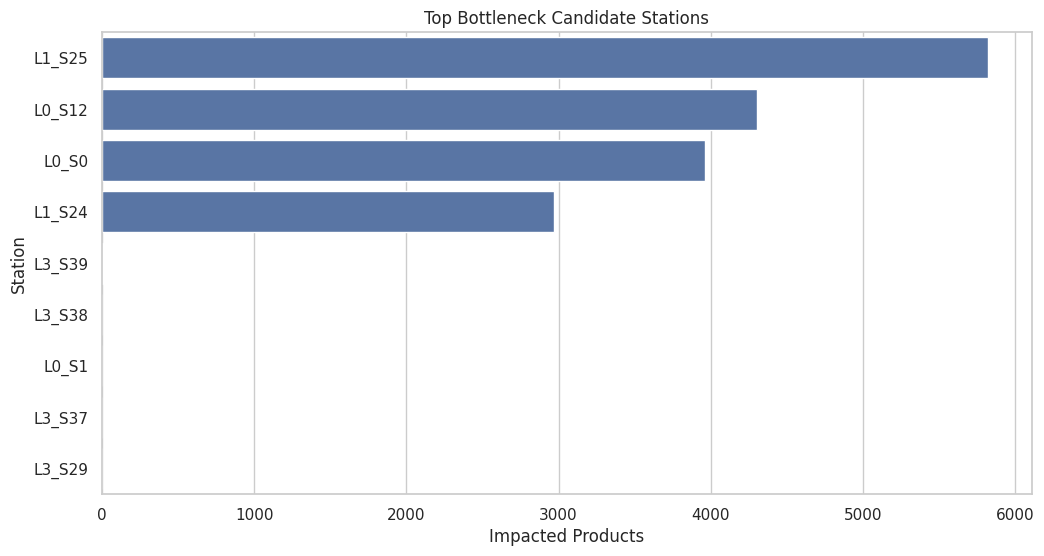

In [12]:

# 병목으로 판단된 제품을 Station별로 집계함
station_risk = (
    iforest_result.loc[
        iforest_result["rule_bottleneck"].eq(1) | iforest_result["iforest_bottleneck"].eq(1)
    ]
    .groupby("bottleneck_station")
    .agg(
        impacted_products=("Id", "count"),
        avg_total_duration=("total_duration", "mean"),
        avg_max_station_span=("max_station_span", "mean"),
        avg_rule_risk=("rule_risk_score", "mean"),
        avg_iforest_risk=("iforest_risk_score", "mean"),
    )
    .sort_values(["impacted_products", "avg_iforest_risk"], ascending=False)
    .head(20)
    .reset_index()
)

display(station_risk)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=station_risk,
    y="bottleneck_station",
    x="impacted_products",
)
plt.title("Top Bottleneck Candidate Stations")
plt.xlabel("Impacted Products")
plt.ylabel("Station")
plt.show()


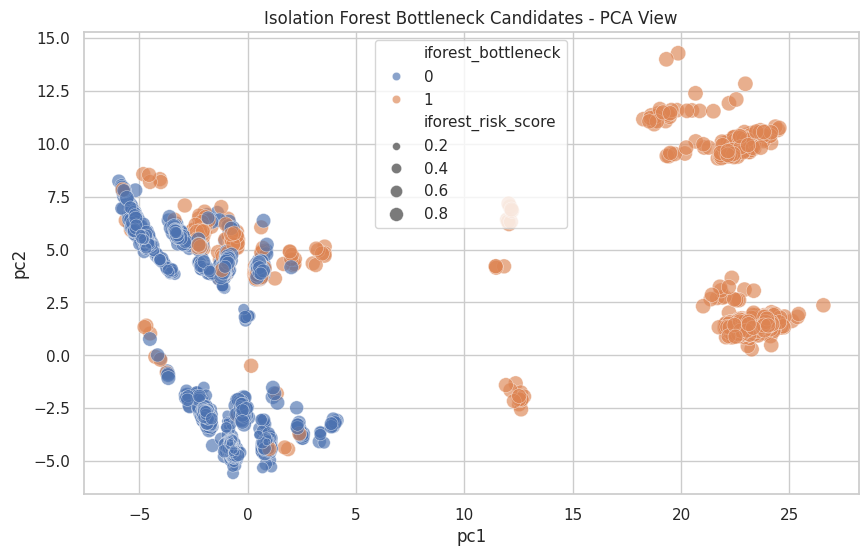

In [13]:

# PCA 시각화를 위해 최대 10,000개 샘플만 사용함
plot_sample = min(len(X), 10000)
plot_index = X.sample(plot_sample, random_state=RANDOM_STATE).index

X_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]).fit_transform(X.loc[plot_index])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_numeric)

pca_df = iforest_result.loc[
    plot_index,
    ["Id", "iforest_bottleneck", "iforest_risk_score"],
].copy()

pca_df["pc1"] = components[:, 0]
pca_df["pc2"] = components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="pc1",
    y="pc2",
    hue="iforest_bottleneck",
    size="iforest_risk_score",
    sizes=(10, 120),
    alpha=0.65,
)
plt.title("Isolation Forest Bottleneck Candidates - PCA View")
plt.show()


## 7. 모델 성능 확인

병목 정답 라벨이 없으므로 Rule Engine 결과를 pseudo label로 사용해 Isolation Forest 결과와 비교합니다.

이 평가는 실제 정답 기준 성능이 아니라, Rule 기준과 비지도학습 모델 결과가 얼마나 겹치는지 확인하는 용도입니다.


== Isolation Forest vs Rule Pseudo Label ==
rule label distribution:
rule_bottleneck
0    91122
1     8878
Name: count, dtype: int64
iforest label distribution:
iforest_bottleneck
0    91122
1     8878
Name: count, dtype: int64
              precision    recall  f1-score   support

           0     0.9095    0.9095    0.9095     91122
           1     0.0715    0.0715    0.0715      8878

    accuracy                         0.8351    100000
   macro avg     0.4905    0.4905    0.4905    100000
weighted avg     0.8351    0.8351    0.8351    100000



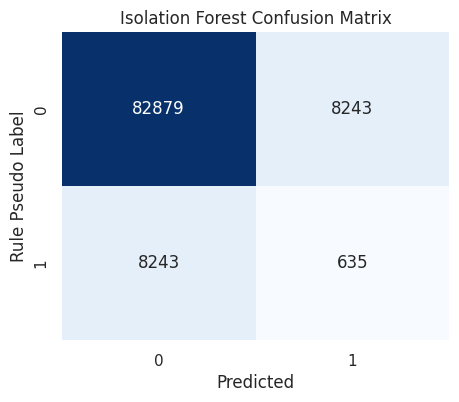

In [14]:

y_true = iforest_result["rule_bottleneck"].astype(int)
y_pred = iforest_result["iforest_bottleneck"].astype(int)

print("== Isolation Forest vs Rule Pseudo Label ==")
print("rule label distribution:")
print(y_true.value_counts(dropna=False))
print("iforest label distribution:")
print(y_pred.value_counts(dropna=False))

print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Rule Pseudo Label")
plt.show()


In [15]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

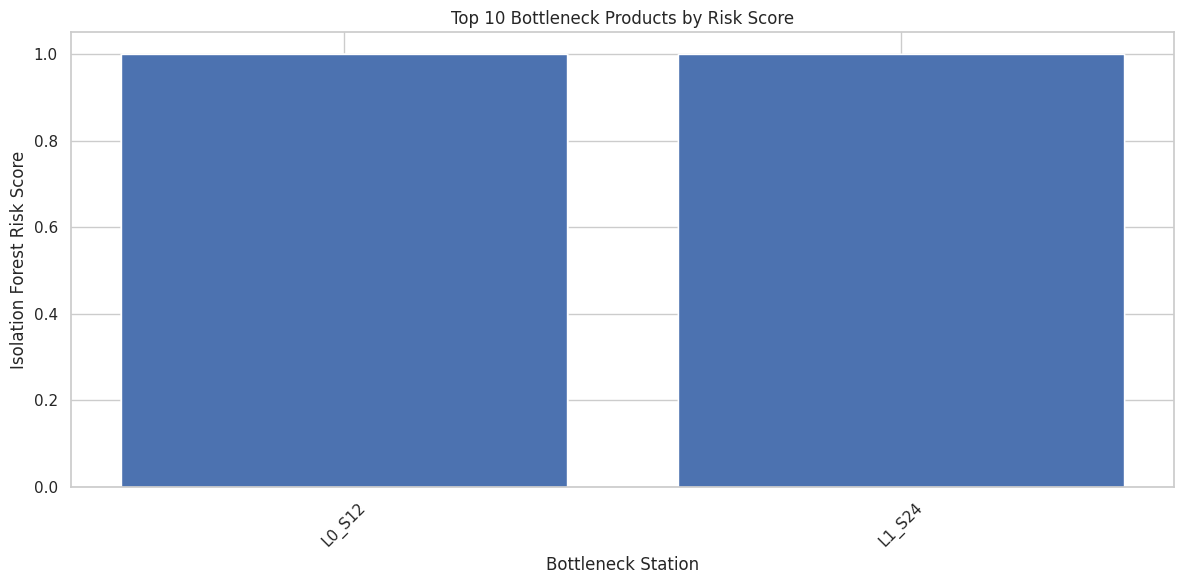

In [16]:
# 병목 위험도 Top 10 시각화

top10_bottleneck = iforest_result.sort_values(
    by='iforest_risk_score',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    top10_bottleneck['bottleneck_station'],
    top10_bottleneck['iforest_risk_score']
)

plt.title('Top 10 Bottleneck Products by Risk Score')
plt.xlabel('Bottleneck Station')
plt.ylabel('Isolation Forest Risk Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

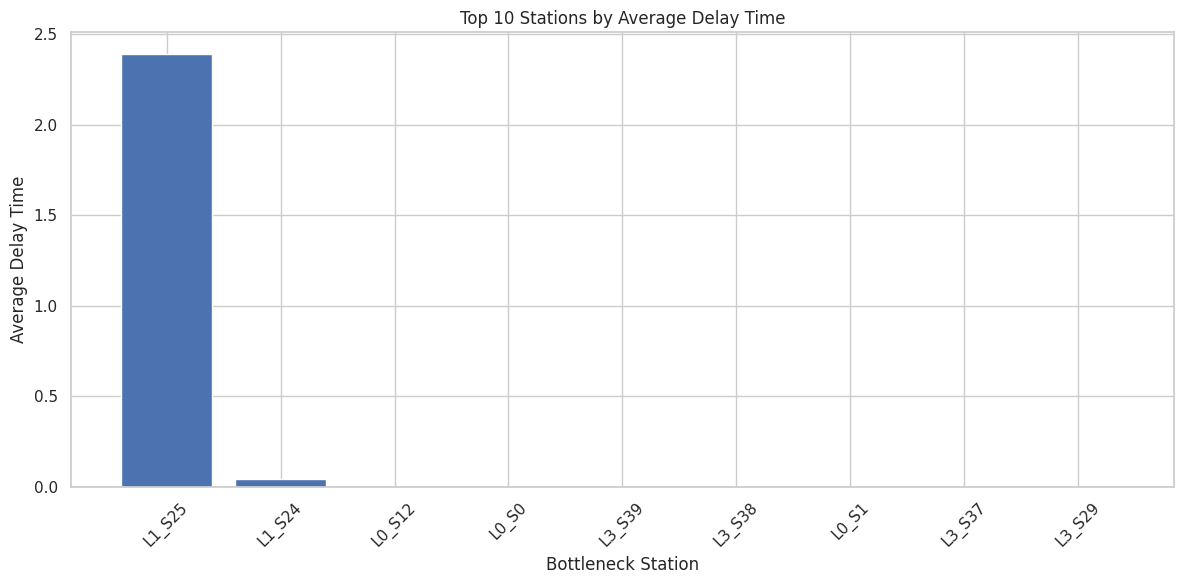

In [17]:
# 평균 지연 시간 Top 10 시각화

top10_delay = station_risk.sort_values(
    by='avg_max_station_span',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    top10_delay['bottleneck_station'],
    top10_delay['avg_max_station_span']
)

plt.title('Top 10 Stations by Average Delay Time')
plt.xlabel('Bottleneck Station')
plt.ylabel('Average Delay Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

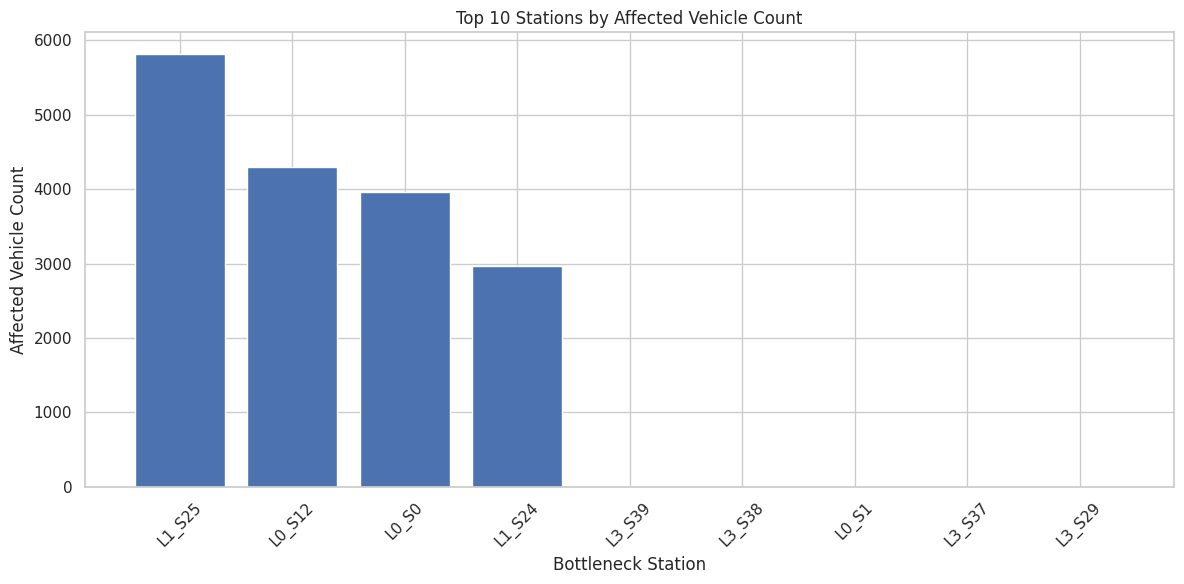

In [18]:
# 3. 영향 차량 수 Top 10 시각화

top10_vehicle = station_risk.sort_values(
    by='impacted_products',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    top10_vehicle['bottleneck_station'],
    top10_vehicle['impacted_products']
)

plt.title('Top 10 Stations by Affected Vehicle Count')
plt.xlabel('Bottleneck Station')
plt.ylabel('Affected Vehicle Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

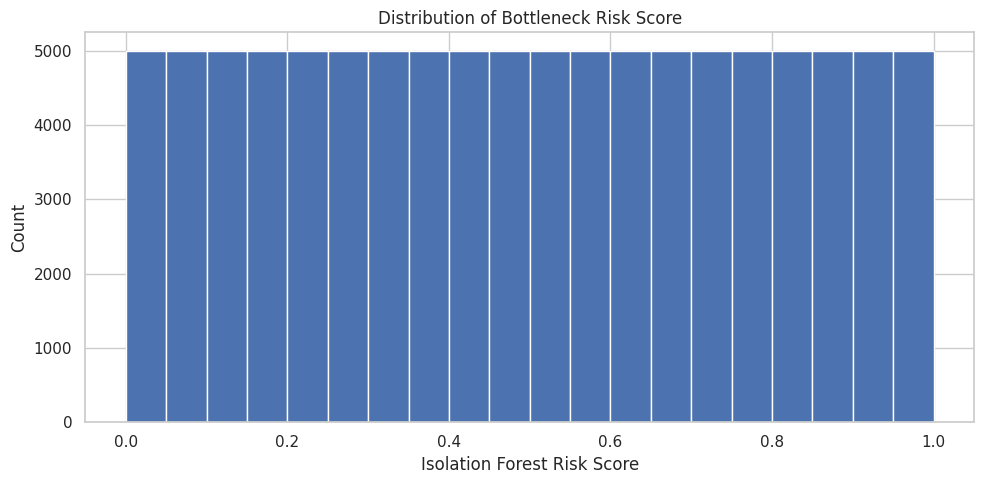

In [19]:
# 4. 병목 위험도 분포 시각화

plt.figure(figsize=(10, 5))
plt.hist(
    iforest_result['iforest_risk_score'],
    bins=20
)

plt.title('Distribution of Bottleneck Risk Score')
plt.xlabel('Isolation Forest Risk Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

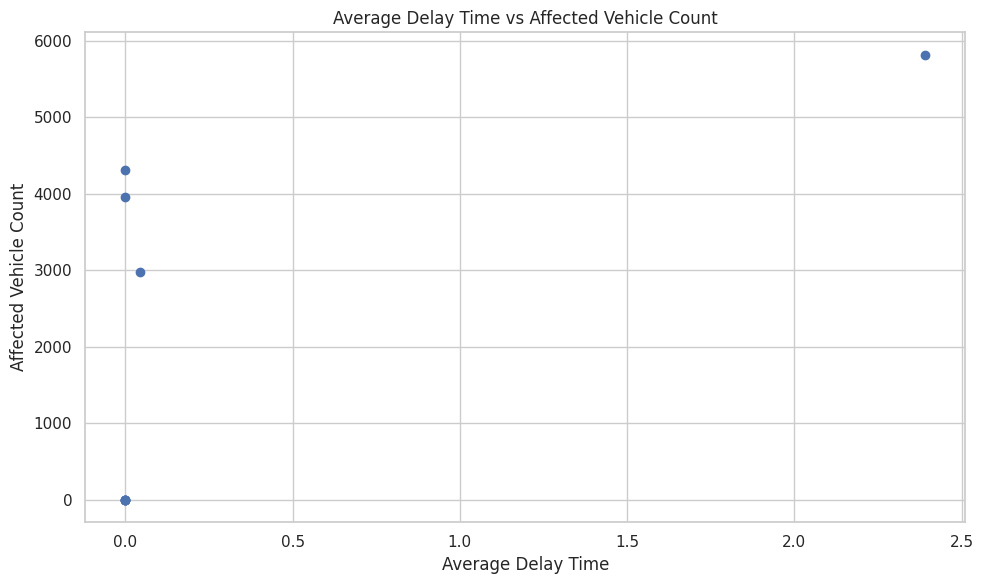

In [20]:
# 5. 평균 지연 시간 vs 영향 차량 수 산점도

plt.figure(figsize=(10, 6))
plt.scatter(
    station_risk['avg_max_station_span'],
    station_risk['impacted_products']
)

plt.title('Average Delay Time vs Affected Vehicle Count')
plt.xlabel('Average Delay Time')
plt.ylabel('Affected Vehicle Count')
plt.tight_layout()
plt.show()

In [21]:
# 6. 병목 위험도 기준 상위 결과 표 출력

display(
    iforest_result.sort_values(
        by='iforest_risk_score',
        ascending=False
    ).head(10)
)

,Id,process_start_time,process_end_time,total_duration,observed_date_count,date_missing_ratio,L0_S0_seen,L0_S0_span,L0_S0_mean_time,L0_S0_std_time,L0_S1_seen,L0_S1_span,L0_S1_mean_time,L0_S1_std_time,L0_S10_seen,L0_S10_span,L0_S10_mean_time,L0_S10_std_time,L0_S11_seen,L0_S11_span,L0_S11_mean_time,L0_S11_std_time,L0_S12_seen,L0_S12_span,L0_S12_mean_time,L0_S12_std_time,L0_S13_seen,L0_S13_span,L0_S13_mean_time,L0_S13_std_time,L0_S14_seen,L0_S14_span,L0_S14_mean_time,L0_S14_std_time,L0_S15_seen,L0_S15_span,L0_S15_mean_time,L0_S15_std_time,L0_S16_seen,L0_S16_span,L0_S16_mean_time,L0_S16_std_time,L0_S17_seen,L0_S17_span,L0_S17_mean_time,L0_S17_std_time,L0_S18_seen,L0_S18_span,L0_S18_mean_time,L0_S18_std_time,L0_S19_seen,L0_S19_span,L0_S19_mean_time,L0_S19_std_time,L0_S2_seen,L0_S2_span,L0_S2_mean_time,L0_S2_std_time,L0_S20_seen,L0_S20_span,L0_S20_mean_time,L0_S20_std_time,L0_S21_seen,L0_S21_span,L0_S21_mean_time,L0_S21_std_time,L0_S22_seen,L0_S22_span,L0_S22_mean_time,L0_S22_std_time,...,L3_S33_num_std,L3_S34_num_seen,L3_S34_num_missing_ratio,L3_S34_num_mean,L3_S34_num_std,L3_S35_num_seen,L3_S35_num_missing_ratio,L3_S35_num_mean,L3_S35_num_std,L3_S36_num_seen,L3_S36_num_missing_ratio,L3_S36_num_mean,L3_S36_num_std,L3_S37_num_seen,L3_S37_num_missing_ratio,L3_S37_num_mean,L3_S37_num_std,L3_S38_num_seen,L3_S38_num_missing_ratio,L3_S38_num_mean,L3_S38_num_std,L3_S39_num_seen,L3_S39_num_missing_ratio,L3_S39_num_mean,L3_S39_num_std,L3_S40_num_seen,L3_S40_num_missing_ratio,L3_S40_num_mean,L3_S40_num_std,L3_S41_num_seen,L3_S41_num_missing_ratio,L3_S41_num_mean,L3_S41_num_std,L3_S43_num_seen,L3_S43_num_missing_ratio,L3_S43_num_mean,L3_S43_num_std,L3_S44_num_seen,L3_S44_num_missing_ratio,L3_S44_num_mean,L3_S44_num_std,L3_S45_num_seen,L3_S45_num_missing_ratio,L3_S45_num_mean,L3_S45_num_std,L3_S47_num_seen,L3_S47_num_missing_ratio,L3_S47_num_mean,L3_S47_num_std,L3_S48_num_seen,L3_S48_num_missing_ratio,L3_S48_num_mean,L3_S48_num_std,L3_S49_num_seen,L3_S49_num_missing_ratio,L3_S49_num_mean,L3_S49_num_std,L3_S50_num_seen,L3_S50_num_missing_ratio,L3_S50_num_mean,L3_S50_num_std,L3_S51_num_seen,L3_S51_num_missing_ratio,L3_S51_num_mean,L3_S51_num_std,rule_risk_score,rule_bottleneck,iforest_bottleneck,iforest_anomaly_score,iforest_risk_score
99498,199312,1400.56,1408.46,7.90,153,0.867647,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1400.56,2.374841e-13,1,0.0,1400.56,0.0,0,NaN,NaN,NaN,1,0.0,1400.57,0.0,1,0.0,1400.59,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1400.60,0.0,0,NaN,NaN,NaN,1,0.0,1400.60,0.0,0,NaN,NaN,NaN,1,0.0,1400.60,2.353541e-13,...,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,1,0.0,0.00000,0.0000,1,0.0,-0.011625,0.080312,1,0.0,-0.047643,0.067577,1,0.0,0.010750,0.018476,0,1.0,NaN,NaN,1,0.0,-0.0228,0.050982,1,0.0,0.019273,0.025578,1,0.0,0.089333,0.192294,1,0.285714,-0.149800,0.334963,1,0.0,-0.036429,0.102833,1,0.0,-0.00025,0.0005,0.050641,0,1,0.175597,1.00000
81200,162806,1400.83,1408.48,7.65,148,0.871972,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1400.83,0.000000e+00,1,0.0,1400.83,0.0,1,0.0,1400.83,0.000000e+00,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1400.84,0.0,0,NaN,NaN,NaN,1,0.0,1400.85,0.0,0,NaN,NaN,NaN,1,0.0,1400.85,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,...,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,1,0.0,0.00000,0.0000,1,0.0,-0.053250,0.060627,1,0.0,-0.044500,0.090663,1,0.0,0.002375,0.008280,0,1.0,NaN,NaN,1,0.0,0.0030,0.004796,1,0.0,0.049727,0.112330,1,0.0,0.087833,0.193089,1,0.000000,-0.039286,0.092937,0,1.0,NaN,NaN,1,0.0,0.00000,0.0000,0.049038,0,1,0.168869,0.99999
80134,160620,1379.62,1399.47,19.85,224,0.806228,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1379.62,2.374841e-13,1,0.0,1379.62,0.0,1,0.0,1379.63,0.000000e+00,0,NaN,NaN,NaN,1,0.0,1379.64,0.0,0,NaN,NaN,NaN,1,0.0,1379.64,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1,0.0,1379.64,0.0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,...,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,0,1.0,NaN,NaN,1,0.

## 8. SHAP 기반 병목 영향 Feature 분석

Isolation Forest 모델의 `decision_function`을 기준으로 SHAP 값을 계산합니다.

주의: 현재 병목 탐지는 실제 정답 라벨이 없는 이상 탐지 방식이므로, SHAP은 "정답 예측 근거"가 아니라 "모델이 병목/이상 점수를 판단할 때 어떤 Feature를 중요하게 사용했는지"를 설명하는 용도입니다.


In [22]:
# SHAP 설치 및 Import
# Colab 환경에서 shap이 없으면 자동 설치합니다.

import sys
import subprocess

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [23]:
# SHAP 분석용 데이터 준비
# 전체 데이터가 크면 계산 시간이 오래 걸리므로 샘플링합니다.

shap_sample_size = min(1000, len(X))
shap_background_size = min(100, len(X))

X_shap = X.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
).copy()

X_background = X.sample(
    n=shap_background_size,
    random_state=RANDOM_STATE
).copy()

# SHAP이 DataFrame 컬럼명을 그대로 사용하도록 숫자형으로 정리합니다.
X_shap = X_shap[model_features].select_dtypes(include=[np.number, "bool"])
X_background = X_background[X_shap.columns]

print("SHAP 분석 데이터 크기:", X_shap.shape)
print("SHAP Background 데이터 크기:", X_background.shape)


SHAP 분석 데이터 크기: (1000, 247)
SHAP Background 데이터 크기: (100, 247)


In [24]:
# Isolation Forest Pipeline 기준 SHAP 계산
# decision_function 값이 낮을수록 이상치에 가깝습니다.
# 따라서 SHAP 값은 "정상 점수 decision_function"에 대한 영향도로 해석합니다.

explainer = shap.Explainer(
    iforest_pipeline.decision_function,
    X_background
)

shap_values = explainer(X_shap)

print("SHAP 계산 완료")
print("SHAP values shape:", shap_values.values.shape)


PermutationExplainer explainer: 1001it [24:21,  1.46s/it]

SHAP 계산 완료
SHAP values shape: (1000, 247)


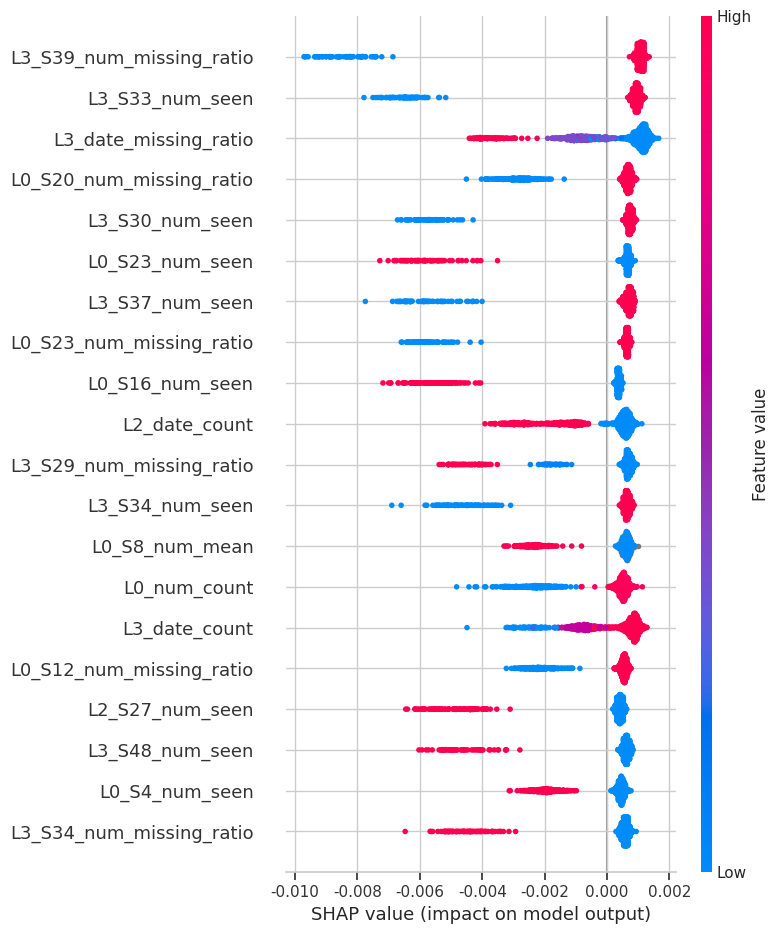

In [25]:
# SHAP Summary Plot
# 모델이 병목/이상 점수를 판단할 때 크게 작용한 Feature를 확인합니다.

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=True
)


In [27]:
# SHAP Feature Importance 표 생성
# mean_abs_shap 값이 클수록 모델 판단에 더 큰 영향을 준 Feature입니다.

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    by="mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print("Top 20 SHAP Feature Importance")
display(shap_importance.head(20))


Top 20 SHAP Feature Importance


,feature,mean_abs_shap
0,L3_S39_num_missing_ratio,0.001520
1,L3_S33_num_seen,0.001360
2,L3_date_missing_ratio,0.001173
3,L0_S20_num_missing_ratio,0.001139
4,L3_S30_num_seen,0.001063
5,L0_S23_num_seen,0.001041
6,L3_S37_num_seen,0.001033
7,L0_S23_num_missing_ratio,0.001026
8,L0_S16_num_seen,0.001000
9,L2_date_count,0.000985


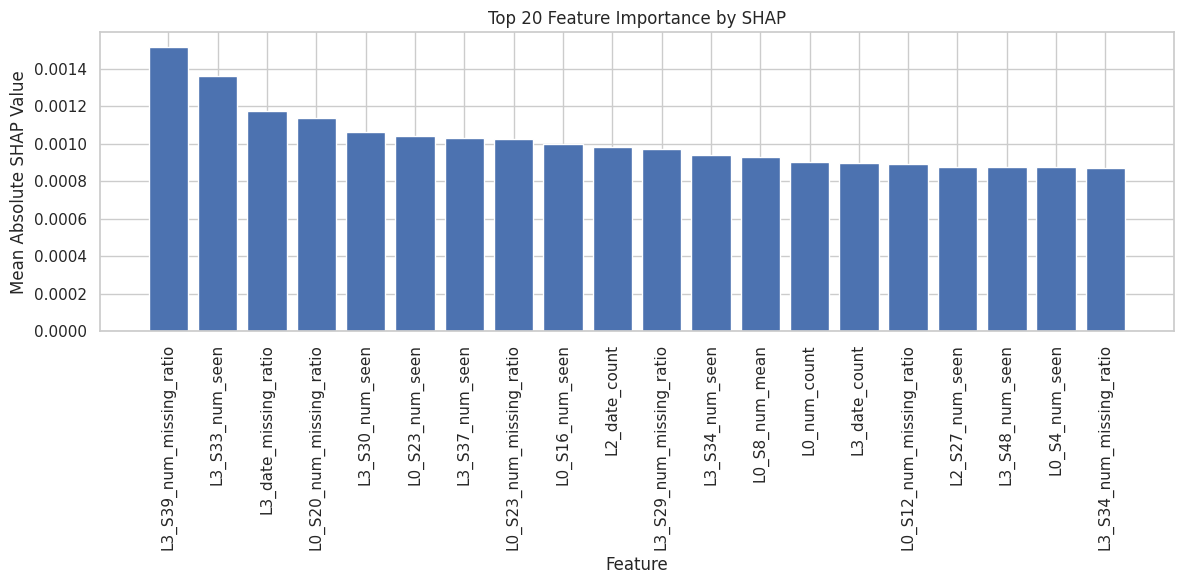

In [28]:
# SHAP Feature Importance Bar Chart

top20_shap = shap_importance.head(20)

plt.figure(figsize=(12, 6))
plt.bar(
    top20_shap["feature"],
    top20_shap["mean_abs_shap"]
)

plt.title("Top 20 Feature Importance by SHAP")
plt.xlabel("Feature")
plt.ylabel("Mean Absolute SHAP Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 9. 병목 탐지 KPI 요약

발표 및 대시보드 연동에 사용할 수 있는 핵심 KPI를 계산합니다.

주요 KPI:

- 전체 분석 제품 수
- 병목 탐지 제품 수
- 병목 탐지 비율
- 병목 발생 Station 수
- 최다 병목 Station
- 평균/최대 병목 위험도
- 평균/최대 지연 시간


In [29]:
# 병목 탐지 KPI 요약

total_products = len(iforest_result)

detected_bottleneck_products = iforest_result[
    iforest_result["iforest_bottleneck"].eq(1)
].shape[0]

rule_bottleneck_products = iforest_result[
    iforest_result["rule_bottleneck"].eq(1)
].shape[0]

bottleneck_rate = detected_bottleneck_products / total_products * 100 if total_products > 0 else 0
rule_bottleneck_rate = rule_bottleneck_products / total_products * 100 if total_products > 0 else 0

total_bottleneck_stations = station_risk["bottleneck_station"].nunique()

top_station = station_risk.sort_values(
    by=["impacted_products", "avg_iforest_risk"],
    ascending=False
).iloc[0]

avg_risk_score = iforest_result["iforest_risk_score"].mean()
max_risk_score = iforest_result["iforest_risk_score"].max()

avg_delay_time = station_risk["avg_max_station_span"].mean()
max_delay_time = station_risk["avg_max_station_span"].max()

avg_impacted_products = station_risk["impacted_products"].mean()
max_impacted_products = station_risk["impacted_products"].max()

kpi_summary = pd.DataFrame({
    "KPI": [
        "전체 분석 제품 수",
        "Rule 기준 병목 제품 수",
        "Rule 기준 병목 비율(%)",
        "Isolation Forest 병목 제품 수",
        "Isolation Forest 병목 비율(%)",
        "병목 발생 Station 수",
        "최다 병목 Station",
        "최다 영향 제품 수",
        "Station 평균 영향 제품 수",
        "평균 병목 위험도",
        "최대 병목 위험도",
        "평균 지연 시간",
        "최대 지연 시간"
    ],
    "Value": [
        total_products,
        rule_bottleneck_products,
        round(rule_bottleneck_rate, 2),
        detected_bottleneck_products,
        round(bottleneck_rate, 2),
        total_bottleneck_stations,
        top_station["bottleneck_station"],
        int(top_station["impacted_products"]),
        round(avg_impacted_products, 2),
        round(avg_risk_score, 4),
        round(max_risk_score, 4),
        round(avg_delay_time, 4),
        round(max_delay_time, 4)
    ]
})

display(kpi_summary)


,KPI,Value
0,전체 분석 제품 수,100000
1,Rule 기준 병목 제품 수,8878
2,Rule 기준 병목 비율(%),8.88
3,Isolation Forest 병목 제품 수,8878
4,Isolation Forest 병목 비율(%),8.88
5,병목 발생 Station 수,9
6,최다 병목 Station,L1_S25
7,최다 영향 제품 수,5818
8,Station 평균 영향 제품 수,1896.78
9,평균 병목 위험도,0.5


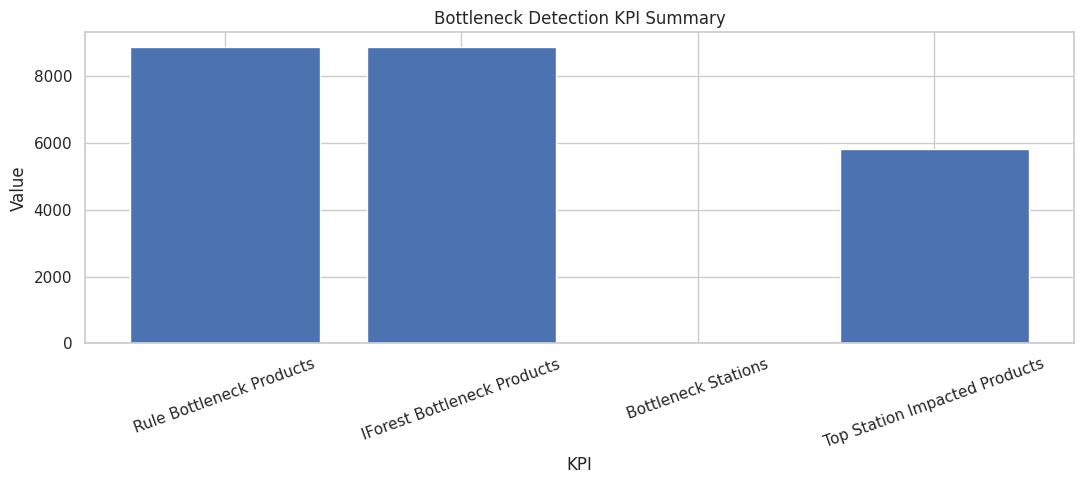

In [30]:
# KPI Bar Chart
# 서로 단위가 다른 값이 섞여 있으므로 개수형 KPI만 따로 시각화합니다.

kpi_chart = pd.DataFrame({
    "Metric": [
        "Rule Bottleneck Products",
        "IForest Bottleneck Products",
        "Bottleneck Stations",
        "Top Station Impacted Products"
    ],
    "Value": [
        rule_bottleneck_products,
        detected_bottleneck_products,
        total_bottleneck_stations,
        int(top_station["impacted_products"])
    ]
})

plt.figure(figsize=(11, 5))
plt.bar(
    kpi_chart["Metric"],
    kpi_chart["Value"]
)

plt.title("Bottleneck Detection KPI Summary")
plt.xlabel("KPI")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [31]:
# 발표용 Station별 KPI Top 10

station_kpi_top10 = station_risk.sort_values(
    by=["impacted_products", "avg_iforest_risk"],
    ascending=False
).head(10).copy()

station_kpi_top10 = station_kpi_top10[[
    "bottleneck_station",
    "impacted_products",
    "avg_total_duration",
    "avg_max_station_span",
    "avg_rule_risk",
    "avg_iforest_risk"
]]

display(station_kpi_top10)


,bottleneck_station,impacted_products,avg_total_duration,avg_max_station_span,avg_rule_risk,avg_iforest_risk
0,L1_S25,5818,42.285889,2.390961,0.525915,0.642507
1,L0_S12,4305,5.995127,0.000000,0.037858,0.947871
2,L0_S0,3960,6.617697,0.000000,0.039752,0.951312
3,L1_S24,2973,50.180340,0.044719,0.387686,0.620131
4,L3_S39,6,0.561667,0.000000,0.003600,0.975422
5,L3_S38,4,0.000000,0.000000,0.000000,0.945802
6,L0_S1,3,0.743333,0.000000,0.004765,0.971167
7,L3_S37,1,0.000000,0.000000,0.000000,0.926370
8,L3_S29,1,0.090000,0.000000,0.000577,0.915190


## 10. 결과 및 모델 저장

Colab에서는 `/content/bottleneck_outputs`에 저장합니다. 로컬 실행 시에는 `app/ml/artifacts`에 저장합니다.

저장 산출물:

- `bottleneck_detection_predictions.csv`
- `bottleneck_station_summary.csv`
- `bottleneck_iforest_model.pkl`
- `bottleneck_model_metadata.pkl`
- `bottleneck_kpi_summary.csv`
- `bottleneck_station_kpi_top10.csv`
- `bottleneck_shap_importance.csv`


In [32]:

import joblib

output_dir = Path("/content/bottleneck_outputs") if Path("/content").exists() else Path("app/ml/artifacts")
output_dir.mkdir(parents=True, exist_ok=True)

prediction_cols = [
    "Id",
    "bottleneck_station",
    "total_duration",
    "max_station_span",
    "active_station_count",
    "rule_risk_score",
    "rule_bottleneck",
    "iforest_anomaly_score",
    "iforest_risk_score",
    "iforest_bottleneck",
]

prediction_path = output_dir / "bottleneck_detection_predictions.csv"
station_path = output_dir / "bottleneck_station_summary.csv"
iforest_model_path = output_dir / "bottleneck_iforest_model.pkl"
metadata_path = output_dir / "bottleneck_model_metadata.pkl"
kpi_summary_path = output_dir / "bottleneck_kpi_summary.csv"
station_kpi_top10_path = output_dir / "bottleneck_station_kpi_top10.csv"
shap_importance_path = output_dir / "bottleneck_shap_importance.csv"

iforest_result[prediction_cols].to_csv(prediction_path, index=False)
station_risk.to_csv(station_path, index=False)

# SHAP/KPI 셀이 실행된 경우 추가 산출물을 함께 저장합니다.
if "kpi_summary" in globals():
    kpi_summary.to_csv(kpi_summary_path, index=False)
if "station_kpi_top10" in globals():
    station_kpi_top10.to_csv(station_kpi_top10_path, index=False)
if "shap_importance" in globals():
    shap_importance.to_csv(shap_importance_path, index=False)

model_metadata = {
    "dataset_files": [DATE_FILENAME, NUMERIC_FILENAME],
    "excluded_columns": ["Response"],
    "modeling_scope": "bottleneck_detection_only",
    "model_features": model_features,
    "rule_thresholds": rule_thresholds,
    "iforest_contamination": contamination,
    "random_state": RANDOM_STATE,
}

joblib.dump(iforest_pipeline, iforest_model_path)
joblib.dump(model_metadata, metadata_path)

print(prediction_path)
print(station_path)
print(iforest_model_path)
print(metadata_path)
if "kpi_summary" in globals():
    print(kpi_summary_path)
if "station_kpi_top10" in globals():
    print(station_kpi_top10_path)
if "shap_importance" in globals():
    print(shap_importance_path)


/content/bottleneck_outputs/bottleneck_detection_predictions.csv
/content/bottleneck_outputs/bottleneck_station_summary.csv
/content/bottleneck_outputs/bottleneck_iforest_model.pkl
/content/bottleneck_outputs/bottleneck_model_metadata.pkl
/content/bottleneck_outputs/bottleneck_kpi_summary.csv
/content/bottleneck_outputs/bottleneck_station_kpi_top10.csv
/content/bottleneck_outputs/bottleneck_shap_importance.csv


## 다음 단계

1. Colab에서 `train_date.csv`와 `train_numeric.csv` 전체 데이터를 사용해 병목 탐지 결과를 확인합니다.
2. 실제 운영 SLA 위반 이력이나 병목 정답 라벨이 생기면 Rule 기준을 실제 라벨 기준으로 교체합니다.
3. 저장된 `bottleneck_iforest_model.pkl`, `bottleneck_model_metadata.pkl`을 `app/ml/artifacts`에 배치합니다.
4. 피처 생성 로직을 `app/ml/features`, 모델 로드 및 추론 로직을 `app/ml/inference`, 학습 스크립트를 `app/ml/training`으로 분리합니다.
5. FastAPI 라우터에서 Product/Station 이벤트를 입력받고 병목 위험도, 병목 후보 Station, 영향 제품 수를 응답하도록 연결합니다.
6. 추론 결과를 Kafka 또는 OpenSearch에 저장해 제조 관제 화면의 병목 알림으로 사용할 수 있게 합니다.
